In [2]:
import numpy as np 
import tensorflow as tf 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense 
from sklearn.datasets import make_blobs 
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

import logging 
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

In [22]:
centers = [[-5, 2], [-2, -2], [1, 2], [5, -2]]
X_train, y_train = make_blobs(n_samples = 5000, centers = centers, cluster_std = 1.0, random_state = 30)


C:\Users\Taiyob Ali\AppData\Local\Temp\ipykernel_9592\3999968102.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


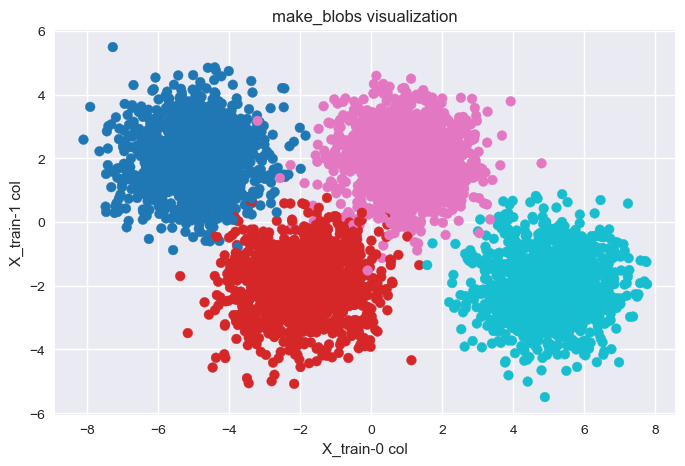

In [23]:
fig, ax = plt.subplots(1,1,figsize=(8,5))
ax.scatter(X_train[:,0],X_train[:,1],c=y_train,cmap="tab10")
ax.set_title("make_blobs visualization")
ax.set_xlabel("X_train-0 col")
ax.set_ylabel("X_train-1 col")
plt.legend()
plt.show()

In [21]:
def my_softmax(z):
    ez = np.exp(z)
    a_activations = ez/np.sum(ez)
    return a_activations

In [24]:
# first way
model = Sequential(
    [
        Dense(units=25, activation="relu"),
        Dense(units=15, activation="relu"),
        Dense(units=4, activation="softmax")
    ]
)


In [25]:
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
loss = SparseCategoricalCrossentropy()
optimizer = Adam(learning_rate=0.001)

model.compile(loss=loss, optimizer=optimizer, metrics=["accuracy"])


In [26]:
model.fit(X_train, y_train, epochs=10)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 730us/step - accuracy: 0.8404 - loss: 0.7052
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 715us/step - accuracy: 0.9856 - loss: 0.1199
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 652us/step - accuracy: 0.9868 - loss: 0.0662
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 690us/step - accuracy: 0.9878 - loss: 0.0512
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 788us/step - accuracy: 0.9874 - loss: 0.0444
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 720us/step - accuracy: 0.9880 - loss: 0.0403
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 671us/step - accuracy: 0.9894 - loss: 0.0367
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 685us/step - accuracy: 0.9888 - loss: 0.0337
Epoch 9/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 737us/step - accuracy: 0.9898 - loss: 0.0318
Epoch 10/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 674us/step - accuracy: 0.9902 - loss: 0.0300


In [29]:
pred = model.predict(X_train[:2])
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
[[1.3635532e-06 7.4672139e-06 5.1796496e-06 9.9998593e-01]
 [1.5191833e-02 9.8343521e-01 1.0905408e-03 2.8245230e-04]]


In [31]:
# second and recommended way

pref_model = Sequential(
    [
        Dense(25, activation="relu"),
        Dense(15, activation="relu"),
        Dense(4)
    ]
)

In [33]:
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
loss_fn = SparseCategoricalCrossentropy(from_logits=True)
optimizer = Adam(learning_rate=0.001)

pref_model.compile(loss=loss_fn, optimizer=optimizer)


In [34]:
pref_model.fit(X_train,y_train,epochs=10)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 624us/step - loss: 0.6620 
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 729us/step - loss: 0.1067
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 677us/step - loss: 0.0593
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 776us/step - loss: 0.0468
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 708us/step - loss: 0.0396
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 750us/step - loss: 0.0359
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 692us/step - loss: 0.0324
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 699us/step - loss: 0.0300
Epoch 9/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 679us/step - loss: 0.0287
Epoch 10/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 755us/step - loss: 0.0273


In [43]:
pred = pref_model.predict(X_train[:1])
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
[[-6.36759   -3.6890082 -3.089687  10.672658 ]]


In [44]:
print(y_train[:1])

[3]


In [45]:
sft = tf.nn.softmax(pred).numpy()
sft

array([[3.9766125e-08, 5.7917140e-07, 1.0546022e-06, 9.9999833e-01]],
      dtype=float32)

In [49]:
idx = np.argmax(sft)
print(y_train[3])

1
